In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import seaborn as sns

In [ ]:
# Import data
tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'KO', 'SPY']
prices = yf.download(tickers, start = '2019-01-01')['Close']
prices.head()

C:\Users\godwi\AppData\Local\Temp\ipykernel_16732\232441875.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start = '2019-01-01')['Close']
[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,JPM,KO,MSFT,NVDA,SPY
Date,,,,,,
2019-01-02,37.575207,81.616707,38.106899,94.789680,3.377354,225.660156
2019-01-03,33.832443,80.456779,37.871422,91.302559,3.173305,220.275284
2019-01-04,35.276722,83.422852,38.626575,95.548973,3.376610,227.653549
2019-01-07,35.198193,83.480858,38.123142,95.670830,3.555371,229.448532
2019-01-08,35.869190,83.323441,38.553501,96.364502,3.466859,231.604279


In [23]:
# Convert into log-returns, calculate mean and covariance
returns = np.log(prices / prices.shift(1)).dropna()
mu = np.array(returns.mean())
cov = returns.cov()
corr = returns.corr()

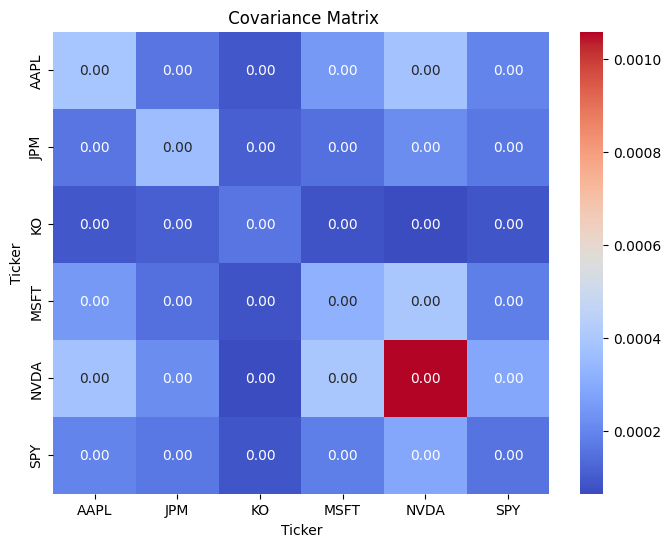

In [24]:
# Visualise correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(cov, annot=True, cmap='coolwarm', fmt = '.2f')
plt.title(' Covariance Matrix')
plt.show()

In [ ]:
# (Optional) PCA Analysis, removing redundant assets reduces complexity
from sklearn.decomposition import PCA
pca = PCA().fit(returns)
pca.explained_variance_ratio_
# PC 1 market factor

array([0.67159032, 0.15819309, 0.08404326, 0.04322943, 0.03751455,
       0.00542936])

Text(0.5, 1.0, 'Rolling 60-Day Volatility')

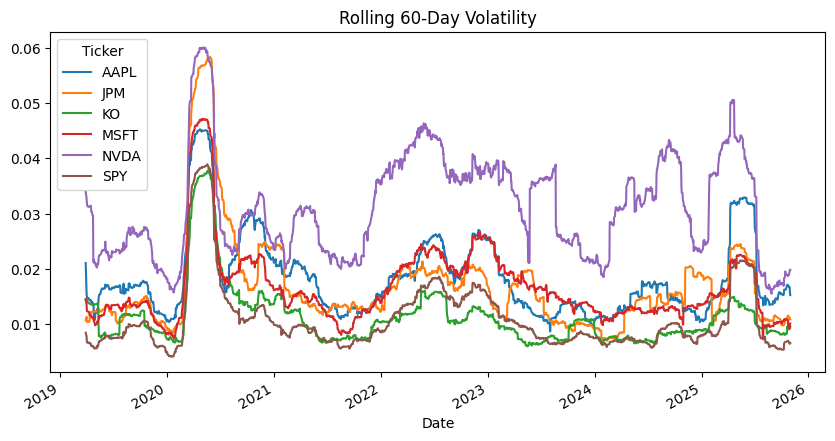

In [25]:
# How volatility changes over time using rolling window of 60 days
returns.rolling(60).std().plot(figsize=(10,5))
plt.title('Rolling 60-Day Volatility')

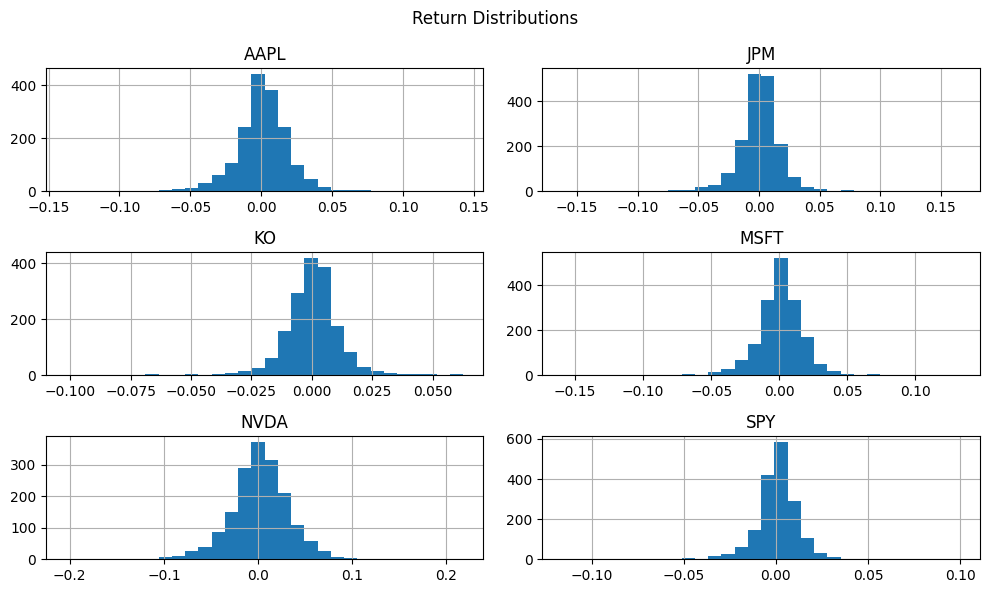

In [28]:
# Return distribution
returns.hist(bins = 30, figsize=(10,6))
plt.suptitle('Return Distributions')
plt.tight_layout()
plt.show()